In [1]:
import pandas as pd
import os
import geopandas as gpd
import blocksnet
import osmnx as ox

In [2]:
ox.settings.overpass_url = "https://overpass.kumi.systems/api/interpreter"

In [4]:
boundaries = ox.geocode_to_gdf('Ижевск')

In [5]:
boundaries_gdf = boundaries
crs = boundaries_gdf.estimate_utm_crs()
boundaries_gdf = boundaries_gdf.to_crs(crs)

In [6]:
boundaries

,geometry,bbox_west,bbox_south,bbox_east,bbox_north,place_id,osm_type,osm_id,lat,lon,class,type,place_rank,importance,addresstype,name,display_name
0,"POLYGON ((53.00656 56.93381, 53.00703 56.93331...",53.006558,56.716406,53.39138,57.004755,184472227,relation,1670935,56.860518,53.197731,place,city,16,0.596319,city,Izhevsk,"Izhevsk, Udmurtia, Volga Federal District, Russia"


In [89]:
input_roads = r"X:\00_ЛабГрад_ПО\09_Сотрудники\Глазов Ю.А\izhevsk\highway_cleaned.gpkg"
input_water = r"X:\00_ЛабГрад_ПО\09_Сотрудники\Глазов Ю.А\izhevsk\water.parquet"
input_railway = r"X:\00_ЛабГрад_ПО\09_Сотрудники\Глазов Ю.А\izhevsk\railway_cleaned.gpkg"

In [90]:
water = gpd.read_parquet(input_water)
roads = gpd.read_file(input_roads)
railways = gpd.read_file(input_railway)

In [91]:
highway_list_mezo = ['living_street', 'primary', 'primary_link', 
                'secondary', 'secondary_link', 'tertiary', 'tertiary_link', 
                'trunk', 'trunk_link', 'unclassified']
highway_list_macro = ['primary', 'primary_link', 
                'secondary', 'secondary_link', 'tertiary', 'tertiary_link', 
                'trunk', 'trunk_link']
railway_list = ['rail']
roads = roads[roads['highway'].isin(highway_list_macro)].copy()
railways = railways[railways['railway'].isin(railway_list)].copy()

In [92]:
water = water[water.geom_type.isin(['Polygon', 'MultiPolygon', 'LineString', 'MultiLineString'])].copy()
roads = roads[roads.geom_type.isin(['LineString', 'MultiLineString'])].copy()
railways = railways[railways.geom_type.isin(['LineString', 'MultiLineString'])].copy()

In [93]:
crs = boundaries.estimate_utm_crs()

for gdf in [roads, railways, boundaries]:
  gdf.to_crs(crs, inplace=True)

In [94]:
from blocksnet.blocks.cutting import preprocess_urban_objects, cut_urban_blocks

lines, polygons = preprocess_urban_objects(roads, railways, water)

2026-02-08 18:57:48.684 | WARNING  | blocksnet.utils.validation.utils:ensure_crs:12 - CRS of GeoDataFrame do not match first provided one. Reprojecting
2026-02-08 18:57:48.689 | INFO     | blocksnet.blocks.cutting.preprocessing.core:preprocess_urban_objects:44 - Checking roads schema
2026-02-08 18:57:48.700 | INFO     | blocksnet.blocks.cutting.preprocessing.core:preprocess_urban_objects:51 - Checking railways schema
2026-02-08 18:57:48.707 | INFO     | blocksnet.blocks.cutting.preprocessing.core:preprocess_urban_objects:58 - Checking water schema


<Axes: >

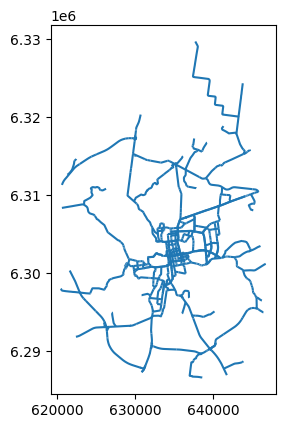

In [99]:
roads.plot()

In [96]:
blocks = cut_urban_blocks(boundaries, lines, polygons)

2026-02-08 18:57:49.863 | INFO     | blocksnet.blocks.cutting.processing.schemas:validate_and_preprocess_gdfs:51 - Checking boundaries schema
2026-02-08 18:57:49.871 | INFO     | blocksnet.blocks.cutting.processing.schemas:validate_and_preprocess_gdfs:55 - Checking line objects schema
2026-02-08 18:57:49.884 | INFO     | blocksnet.blocks.cutting.processing.schemas:validate_and_preprocess_gdfs:62 - Checking polygon objects schema
2026-02-08 18:57:49.886 | WARNING  | blocksnet.blocks.cutting.processing.schemas:validate_and_preprocess_gdfs:64 - Creating empty polygon objects
2026-02-08 18:57:49.888 | INFO     | blocksnet.blocks.cutting.processing.schemas:validate_and_preprocess_gdfs:69 - Checking buildings schema
2026-02-08 18:57:49.889 | WARNING  | blocksnet.blocks.cutting.processing.schemas:validate_and_preprocess_gdfs:71 - Creating empty buildings
2026-02-08 18:57:50.020 | SUCCESS  | blocksnet.blocks.cutting.processing.core:cut_urban_blocks:26 - 398 blocks are successfully cut


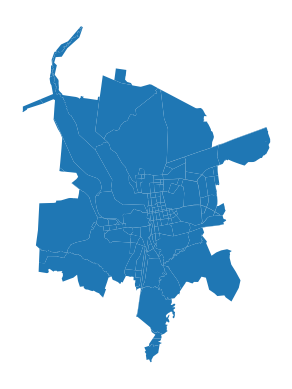

In [97]:
blocks.plot().set_axis_off()


In [98]:
blocks.to_file(r"X:\00_ЛабГрад_ПО\09_Сотрудники\Глазов Ю.А\izhevsk\blocks.gpkg", driver='GPKG', layer='blocks')

In [71]:
buildings_gdf = gpd.read_parquet(r"X:\00_ЛабГрад_ПО\09_Сотрудники\Глазов Ю.А\izhevsk\OVM\buildings_OVM.geoparquet").reset_index()